In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load the Advertising dataset

df = pd.read_csv("Advertising.csv")

# Display the first 5 rows
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
# Check the shape of the dataset
print("Dataset Shape:", df.shape)

# Check data types and basic information
print("\nDataset Information:")
df.info()

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check descriptive statistics
print("\nDescriptive Statistics:")
df.describe()

Dataset Shape: (200, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB

Missing Values:
Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

Descriptive Statistics:


,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [4]:
# Remove the unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

# Check the dataset again
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


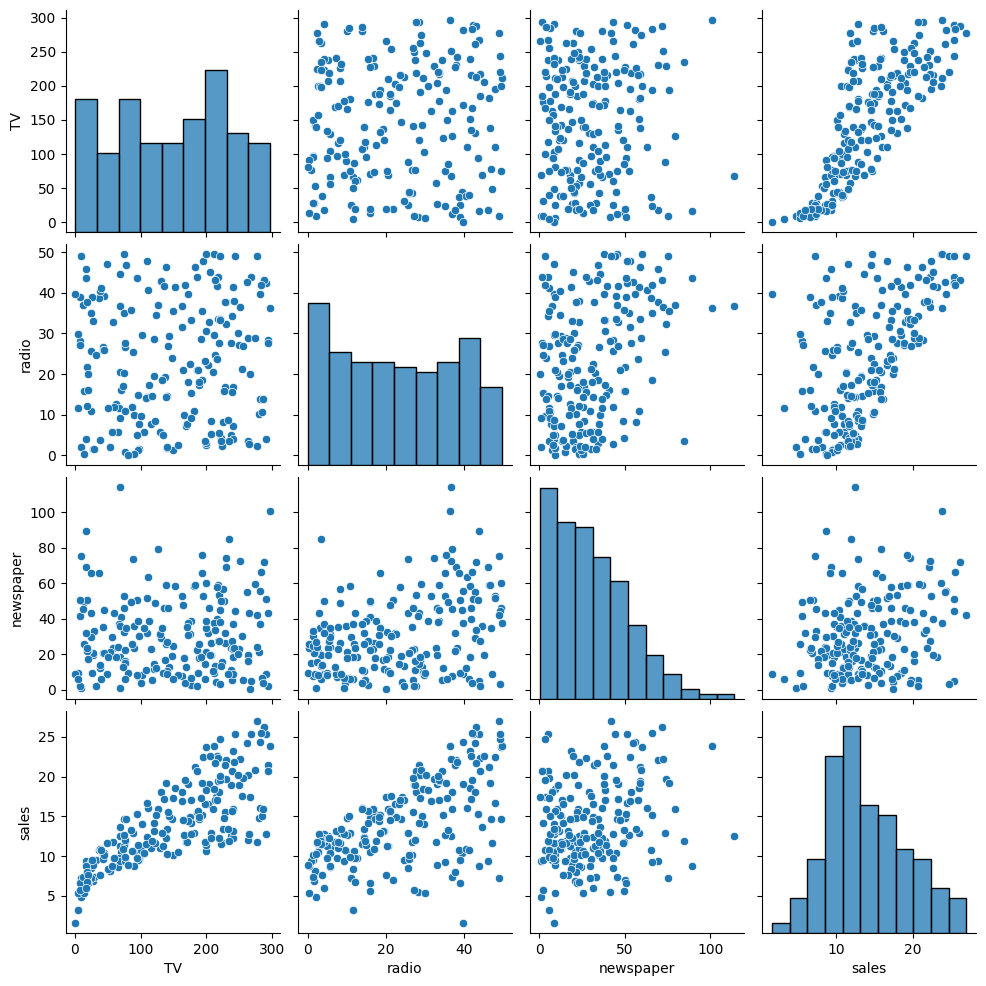

In [5]:
# Pairplot to visualize relationships between all variables

sns.pairplot(df)
plt.show()

### Observation

The pairplot shows that Sales has the strongest positive relationship with TV advertising, followed by Radio advertising. Newspaper advertising shows a comparatively weaker relationship with Sales.

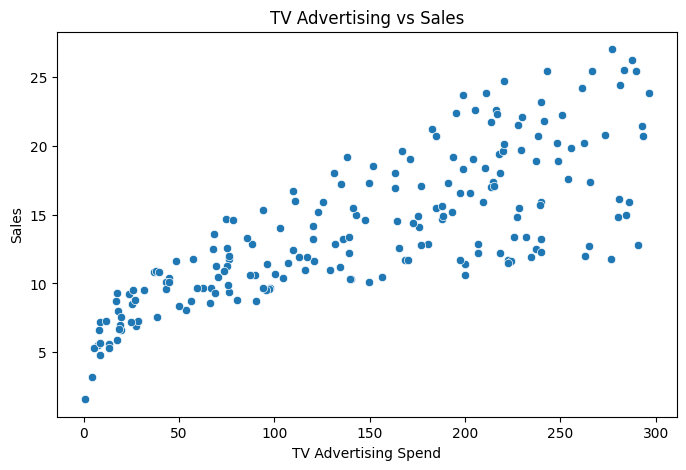

In [6]:
# Scatter plot: TV Advertising vs Sales

plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="TV", y="sales")

plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")

plt.show()

### Observation

The plot shows a clear positive relationship between TV advertising and Sales. As the amount spent on TV advertising increases, Sales generally tend to increase as well. This indicates that TV advertising plays an important role in driving sales.

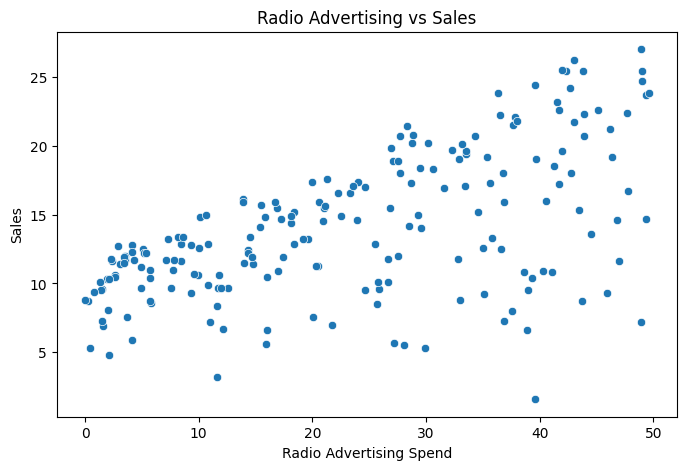

In [7]:
# Scatter plot: Radio Advertising vs Sales

plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="radio", y="sales")

plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")

plt.show()

### Observation

The plot shows a positive relationship between Radio advertising and Sales. Although the points are somewhat scattered, higher Radio advertising expenditure generally corresponds to higher Sales, suggesting that Radio advertising also contributes to sales growth.

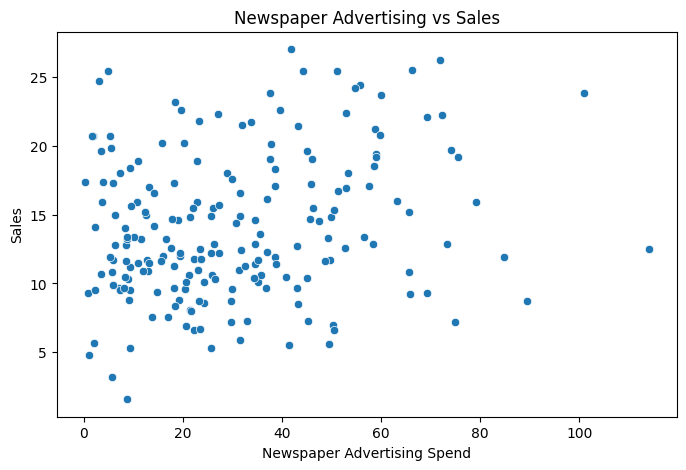

In [8]:
# Scatter plot: Newspaper Advertising vs Sales

plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="newspaper", y="sales")

plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")

plt.show()

### Observation

The plot shows a positive but relatively weak relationship between Newspaper advertising and Sales. The points are more widely scattered compared with TV and Radio, suggesting that Newspaper advertising has a smaller influence on Sales.

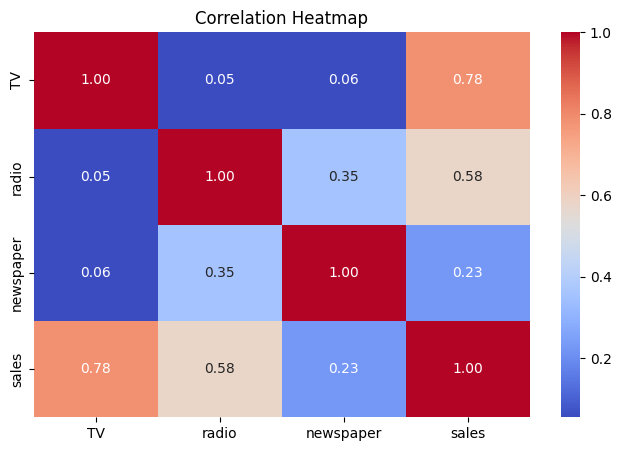

In [9]:
# Calculate correlations between advertising channels and sales
correlation = df.corr(numeric_only=True)

# Create the correlation heatmap
plt.figure(figsize=(8, 5))

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

### Observation

The heatmap shows that TV advertising has the strongest positive correlation with Sales, followed by Radio advertising. Newspaper advertising has a comparatively weaker correlation with Sales. This suggests that TV advertising has the strongest linear relationship with Sales among the three advertising channels.

In [10]:
# Define input features and target variable

X = df[["TV", "radio", "newspaper"]]
y = df["sales"]

# Display the features
X.head()

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [11]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check the sizes of the training and testing data
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [12]:
# Create and train the Linear Regression model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_linear = linear_model.predict(X_test)

# Display the first 5 predictions
print("First 5 Predictions:")
print(y_pred_linear[:5])

First 5 Predictions:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326]


In [13]:
# Evaluate the Linear Regression model

mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression Performance
MAE : 1.4607567168117606
RMSE: 1.7815996615334502
R²  : 0.899438024100912


### Linear Regression – Observation

The Linear Regression model achieved an R² score of approximately 89.94%, which indicates that the model explains most of the variation in Sales. The MAE of 1.46 means that the predicted sales values are, on average, about 1.46 units away from the actual values.

In [14]:
# Create and train the Random Forest Regression model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)

# Display the first 5 predictions
print("First 5 Predictions:")
print(y_pred_rf[:5])

First 5 Predictions:
[17.698 21.804 20.628  6.793 22.927]


In [15]:
# Evaluate the Random Forest Regression model

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Performance")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regression Performance
MAE : 0.6200999999999988
RMSE: 0.7685910811348248
R²  : 0.9812843792541843


In [16]:
# Compare the performance of both regression models

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_linear, mae_rf],
    "RMSE": [rmse_linear, rmse_rf],
    "R²": [r2_linear, r2_rf]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.620100,0.768591,0.981284


### Model Comparison – Observation

Random Forest performed better than Linear Regression on the test data. It achieved a lower MAE and RMSE, while its R² score was higher at approximately 98.13%. Therefore, Random Forest is selected as the better-performing model for this dataset.

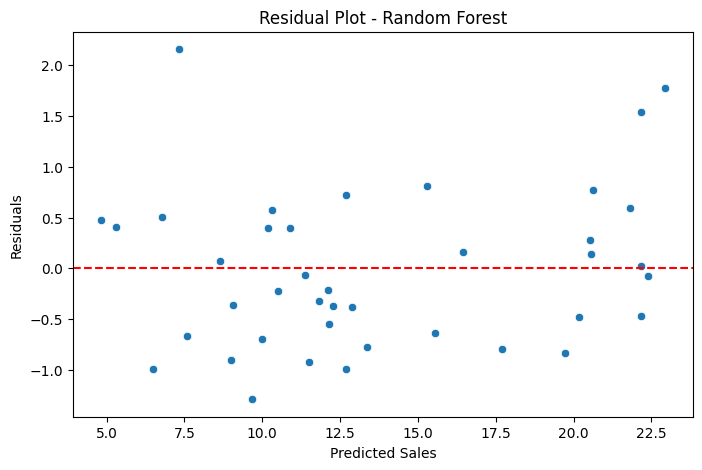

In [17]:
# Calculate residuals for the Random Forest model

residuals = y_test - y_pred_rf

# Create the residual plot
plt.figure(figsize=(8, 5))

sns.scatterplot(x=y_pred_rf, y=residuals)

plt.axhline(y=0, color="red", linestyle="--")

plt.title("Residual Plot - Random Forest")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.show()

### Residual Plot – Observation

The residuals are distributed around the zero line without a clear pattern. Most of the points are relatively close to zero, which indicates that the Random Forest model is making reasonably accurate predictions on the test data.

In [18]:
# Get feature importance from the Random Forest model

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display feature importance
feature_importance

,Feature,Importance
0,TV,0.624810
1,radio,0.362201
2,newspaper,0.012989


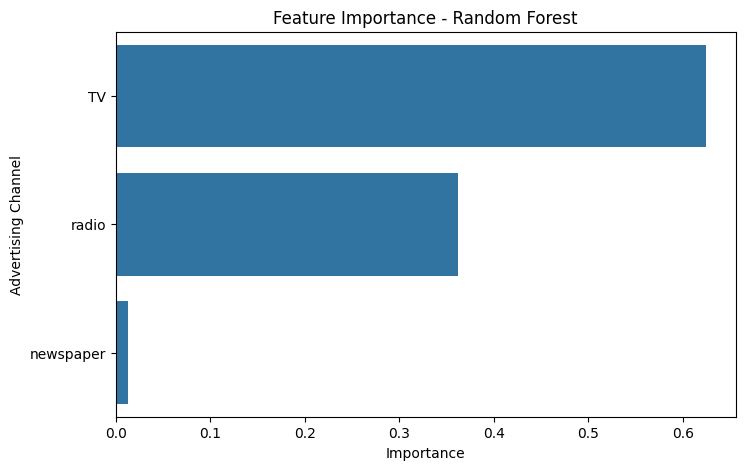

In [19]:
# Plot feature importance

plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")

plt.show()

### Feature Importance – Observation

The feature importance plot shows that TV advertising has the highest importance in predicting Sales, followed by Radio advertising. Newspaper advertising has very low importance compared with the other two channels. This suggests that TV and Radio advertising have a much stronger influence on the model's sales predictions.

## Conclusion

This project analyzed the relationship between advertising expenditure and product sales using Python and machine learning.

The analysis showed that TV advertising has the strongest relationship with Sales, followed by Radio advertising, while Newspaper advertising has a much weaker relationship.

Two regression models were trained and evaluated: Linear Regression and Random Forest Regression. Random Forest performed better, achieving an R² score of approximately 98.13%, with an MAE of 0.62 and RMSE of 0.77.

Feature importance from the Random Forest model showed that TV advertising was the most important feature, followed by Radio and Newspaper.

Overall, the results suggest that TV and Radio advertising were the most influential channels for predicting Sales in this dataset.